### Revision Exercises (Multiple Lineaar Regression)

In [21]:
from pathlib import Path
import sys

current_dir = Path.cwd()
project_root = current_dir.parent.absolute()

sys.path.insert(0,str(project_root))

from config import S_ML

In [22]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt


In [23]:
# loading the dataset
df = pd.read_csv(S_ML)

print(f'Shape of the Dataset:{df.shape}')
print(f'Missing the values in each columns:\n{df.isnull().sum()}')

print(f'Dataset:{df.head()}')

Shape of the Dataset:(30, 6)
Missing the values in each columns:
Area              0
Bedrooms          0
Age               0
DistanceToCity    0
HasGarage         0
Price             0
dtype: int64
Dataset:   Area  Bedrooms  Age  DistanceToCity  HasGarage   Price
0  1500         3   10               5          1  245000
1  1200         2   15               8          0  185000
2  1800         4    5               3          1  320000
3   950         2   20              12          0  135000
4  2100         4    3               2          1  410000


<Axes: >

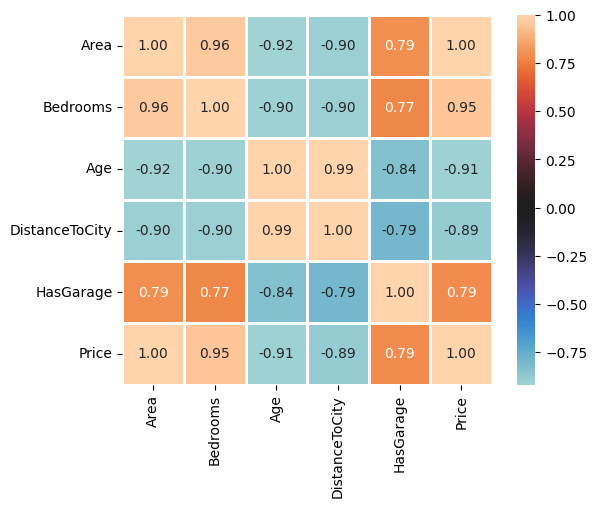

In [24]:
# visualize of heatmap
import seaborn as sns
correlation = df.corr()

sns.heatmap(correlation,center=0,annot=True,fmt='.2f',linewidth=2, square=True)


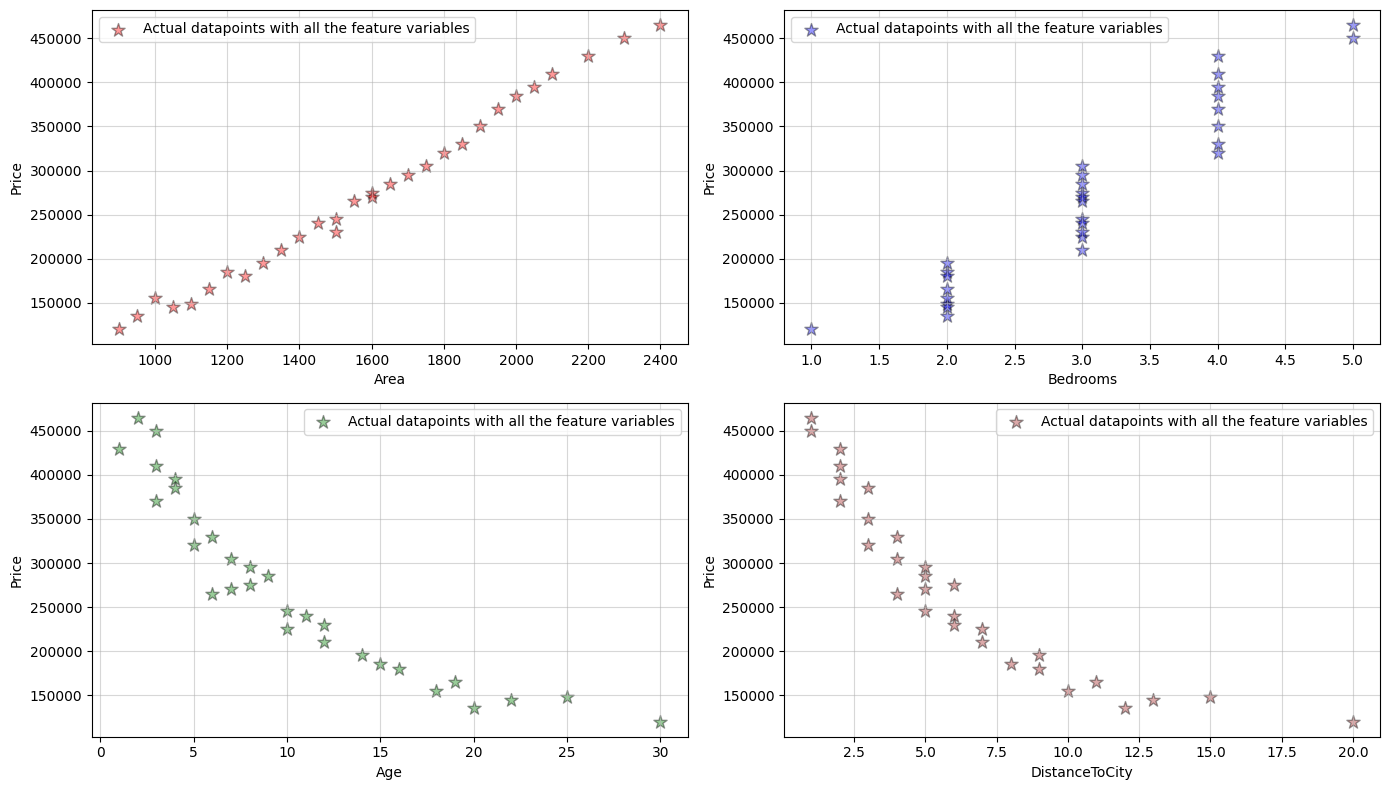

In [25]:
features = ['Area','Bedrooms','Age','DistanceToCity']
colors = ['r','blue','green','brown']

fig, axes = plt.subplots(2,2,figsize=(14,8))
axes = axes.ravel()

for i, col in enumerate(features):
    axes[i].scatter(df[col], df['Price'], marker='*', color=colors[i],label='Actual datapoints with all the feature variables',alpha=0.4,s=100, edgecolor='black')
    axes[i].set_ylabel('Price')
    axes[i].set_xlabel(f'{col}')
    axes[i].legend()
    axes[i].grid(True,alpha=0.5)
plt.tight_layout()
plt.show()


In [26]:
#splitting the feature and target variable
X = df.drop('Price',axis=1)
y = df[['Price']].values

In [27]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [30]:
#training multiple linear regressio model
from sklearn.linear_model import LinearRegression

regressor = LinearRegression()
regressor.fit(X_train,y_train)
pred_y_train = regressor.predict(X_train)
pred_y_test = regressor.predict(X_test)

In [43]:
#Display the coef for all the features
for feature, coef in zip(X.columns,regressor.coef_.ravel()):
    print(f'{feature} : {coef:.2f}')
print(f'Intercept is {regressor.intercept_[0]:.2f}')

Area : 228.12
Bedrooms : 7968.69
Age : -1563.21
DistanceToCity : 3131.88
HasGarage : -550.63
Intercept is -115471.97


In [47]:
# Evalution 
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
R2_score = r2_score(y_test, pred_y_test)
mae = mean_absolute_error(y_test, pred_y_test)
mse = np.sqrt(mean_squared_error(y_test,pred_y_test))

print(f'R2 Score : {R2_score:.2f}')
print(f'Mean Absolute Error: {mae:.2f}')
print(f'Mean Squared Error: {mse:.2f}')

R2 Score : 0.99
Mean Absolute Error: 5796.78
Mean Squared Error: 6959.53


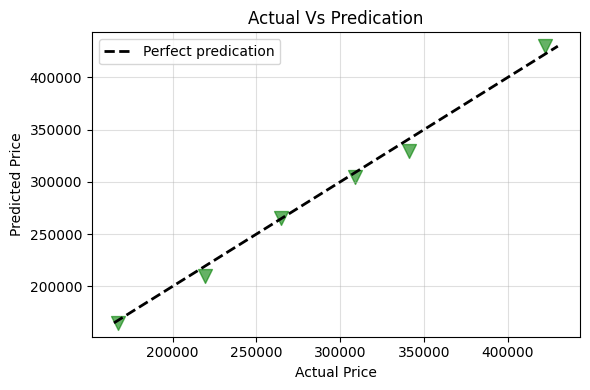

In [51]:
# Actual and Predicted 
plt.figure(figsize=(6,4))
plt.scatter(pred_y_test,y_test,marker='v',s=100,color='green',alpha=0.6)
min_value = min(y_test.min(), pred_y_test.min())
max_value = max(y_test.max(),pred_y_test.max())
plt.plot([min_value,max_value],[min_value,max_value],'--k',label='Perfect predication',linewidth=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual Vs Predication')
plt.grid(True,alpha=0.4)
plt.tight_layout()
plt.legend()
plt.show()

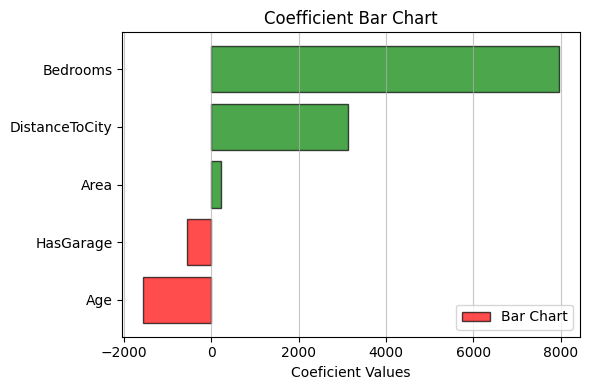

In [59]:
#coefficient bar chart
plt.figure(figsize=(6,4))
coef_df = pd.DataFrame({
    'Features': X.columns,
    'Coefficients': regressor.coef_.ravel()
})
coef_df = coef_df.sort_values('Coefficients',ascending=True)
colors = ['r' if c <  0 else 'green' for c in coef_df['Coefficients']]
plt.barh(coef_df['Features'],coef_df['Coefficients'],color=colors,label='Bar Chart',edgecolor='black',alpha=0.7)
plt.xlabel('Coeficient Values')
plt.title('Coefficient Bar Chart')
plt.tight_layout()
plt.grid(True,alpha=0.7,axis='x')
plt.legend()
plt.show()